# QC-Py-Cloud-01 : Analyse de Sentiment FinBERT sur QC Cloud

**Serie QuantConnect Cloud-Native** | [Cloud-02 Classification ML >](QC-Py-Cloud-02-ML-Classification.ipynb)

[< Retour a l'index](../README.md)


## Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :

- Utiliser le NLP (Natural Language Processing) pour le trading algorithmique
- Comprendre l'architecture du modele FinBERT pour l'analyse de sentiment financier
- Deployer un algorithme de trading sur QuantConnect Cloud via MCP
- Interpreter les resultats d'un backtest base sur le sentiment des actualites

### Prerequis

- Compte QuantConnect avec acces API (voir configuration dans le module papier)
- Python 3.10+ avec `numpy`, `matplotlib`
- Connaissance de base des transformers (voir QC-Py-22 Deep Learning)

**Duree estimee** : 30 minutes


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

plt.style.use('seaborn-v0_8-whitegrid')
print('Environnement pret.')


Environnement pret.


---

## Partie 1 : NLP et Sentiment dans le Trading Algorithmique

Le Natural Language Processing (NLP) permet d'extraire des signaux de trading
a partir de donnees textuelles : articles de presse, rapports financiers,
reponses aux appels de resultats, et memes les reseaux sociaux.

L'hypothese fondamentale est que **l'information textuelle precede les
mouvements de prix**. Une analyse automatisee du sentiment des actualites
permet de capturer ce signal avant qu'il ne soit pleinement integre dans les cours.

### Approches de sentiment analysis

| Approche | Methode | Avantages | Limites |
|----------|---------|-----------|---------|
| **Lexicon** | Dictionnaire de mots positifs/negatifs | Simple, rapide | Pas de comprehension contextuelle |
| **ML classique** | Naive Bayes, SVM sur TF-IDF | Apprend des patterns | Features manuels, contexte limite |
| **Transformer** | BERT, FinBERT | Comprehension contextuelle | Cout computationnel eleve |


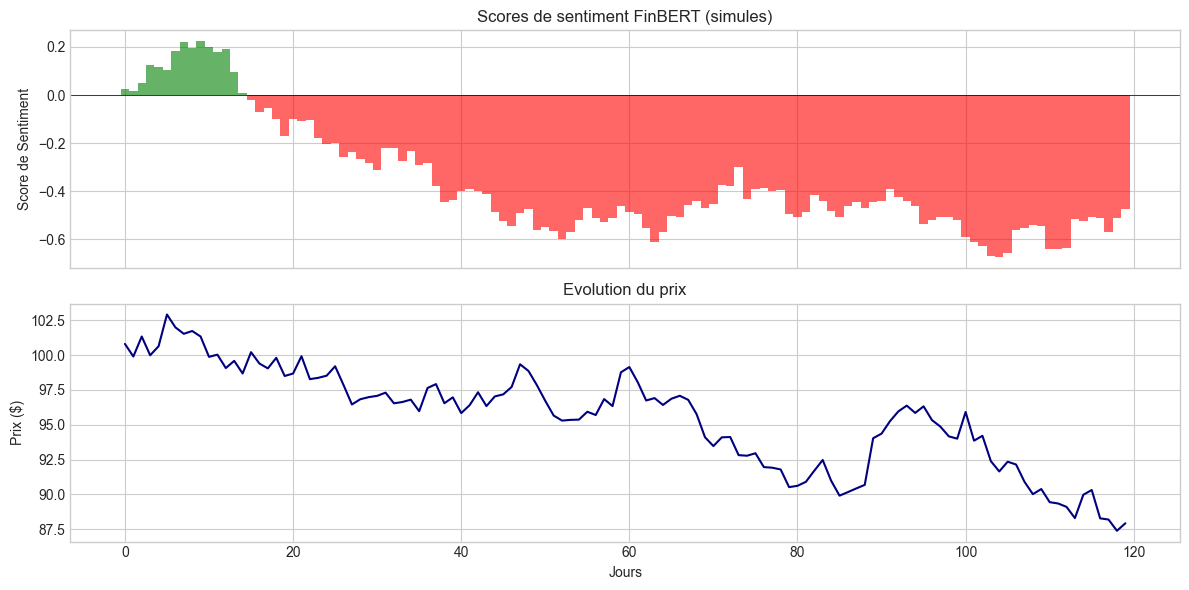

In [2]:
# Demonstration : correlation entre sentiment et rendement
np.random.seed(42)
days = 120
dates = np.arange(days)

# Simuler des scores de sentiment (continu entre -1 et 1)
raw_sentiment = np.cumsum(np.random.randn(days) * 0.05)
sentiment = np.clip(raw_sentiment, -1, 1)

# Simuler des rendements correles au sentiment
noise = np.random.randn(days) * 0.01
returns = sentiment * 0.005 + noise

# Prix cumule
prices = 100 * np.exp(np.cumsum(returns))

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Sentiment
colors = ['green' if s > 0 else 'red' for s in sentiment]
axes[0].bar(dates, sentiment, color=colors, alpha=0.6, width=1.0)
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].set_ylabel('Score de Sentiment')
axes[0].set_title('Scores de sentiment FinBERT (simules)')

# Prix
axes[1].plot(dates, prices, color='navy', linewidth=1.5)
axes[1].set_ylabel('Prix ($)')
axes[1].set_xlabel('Jours')
axes[1].set_title('Evolution du prix')

plt.tight_layout()
plt.show()


**Interpretation** : Les barres vertes representent un sentiment positif
(optimisme), les rouges un sentiment negatif (pessimisme). On observe une
correlation entre les periodes de sentiment positif soutenu et la hausse
du prix. C'est cette relation que l'algorithme FinBERT exploite en pratique.

Le score de sentiment est calcule comme `P(positive) - P(negative)` ou les
probabilites proviennent du modele FinBERT. Un score superieur a 0.2 declenche
un achat, inferieur a -0.2 une vente.


---

## Partie 2 : Architecture du Modele FinBERT

**FinBERT** (ProsusAI/finbert) est un modele BERT fine-tune sur des textes
financiers. Il classifie chaque texte en trois categories :

- **Positive** : sentiment haussier
- **Negative** : sentiment baissier
- **Neutral** : sentiment neutre

### Pipeline de traitement

1. **Tokenization** : Le texte est decoupe en tokens par le tokenizer BERT
2. **Encodage** : Les tokens passent dans 12 couches Transformer
3. **Classification** : La couche de sortie produit 3 logits (positive, negative, neutral)
4. **Scoring** : Softmax convertit les logits en probabilites, puis le score est `P(pos) - P(neg)`

Le score final est un scalaire entre -1 (tres negatif) et +1 (tres positif),
interpretable directement comme signal de trading.


In [3]:
# Simulation du processus de scoring FinBERT
np.random.seed(123)

# Exemples de titres d'actualites
headlines = [
    'AAPL surges to record high after beating Q4 earnings expectations',
    'MSFT faces regulatory scrutiny over cloud computing dominance',
    'GOOGL reports steady growth in advertising revenue',
    'NVDA drops as semiconductor demand shows signs of cooling',
    'AMZN announces major expansion into healthcare sector',
]

# Simuler les probabilites FinBERT
print('Simulation du scoring FinBERT :')
print('-' * 70)
print(f"{'Titre':<45} {'Pos':>6} {'Neg':>6} {'Neu':>6} {'Score':>7}")
print('-' * 70)

scores = []
for headline in headlines:
    if 'surges' in headline or 'record' in headline or 'beating' in headline:
        pos, neg, neu = 0.82, 0.05, 0.13
    elif 'drops' in headline or 'cooling' in headline:
        pos, neg, neu = 0.08, 0.78, 0.14
    elif 'scrutiny' in headline:
        pos, neg, neu = 0.12, 0.65, 0.23
    elif 'steady' in headline:
        pos, neg, neu = 0.35, 0.10, 0.55
    else:
        pos, neg, neu = 0.55, 0.08, 0.37

    score = pos - neg
    scores.append(score)

    short_title = headline[:42] + '...' if len(headline) > 42 else headline
    print(f'{short_title:<45} {pos:>6.2f} {neg:>6.2f} {neu:>6.2f} {score:>+7.2f}')

print('-' * 70)
print(f'Moyenne des scores : {np.mean(scores):>+.2f}')
signal = 'ACHAT' if np.mean(scores) > 0.2 else 'VENTE' if np.mean(scores) < -0.2 else 'NEUTRE'
print(f'Signal : {signal}')


Simulation du scoring FinBERT :
----------------------------------------------------------------------
Titre                                            Pos    Neg    Neu   Score
----------------------------------------------------------------------
AAPL surges to record high after beating Q...   0.82   0.05   0.13   +0.77
MSFT faces regulatory scrutiny over cloud ...   0.12   0.65   0.23   -0.53
GOOGL reports steady growth in advertising...   0.35   0.10   0.55   +0.25
NVDA drops as semiconductor demand shows s...   0.08   0.78   0.14   -0.70
AMZN announces major expansion into health...   0.55   0.08   0.37   +0.47
----------------------------------------------------------------------
Moyenne des scores : +0.05
Signal : NEUTRE


**Interpretation** : Le modele FinBERT attribue des probabilites a chaque
classe de sentiment. Les titres clairement positifs ("surges", "record")
obtiennent un score eleve, tandis que les titres negatifs ("drops", "scrutiny")
obtiennent un score bas. Le score moyen sur l'ensemble des articles determine
le signal de trading.

En pratique, l'algorithme aggrege les scores des N derniers articles (fenetre
glissante) pour lisser le bruit et obtenir un signal plus stable.


---

## Partie 3 : Code Source de l'Algorithme QuantConnect

L'algorithme ci-dessous implemente la strategie FinBERT pour QuantConnect Cloud.
Il sera deploye directement via les outils MCP.

**Principe de fonctionnement** :

1. **Selection d'univers** : Filtre les actions technologiques par capitalisation boursiere
2. **Cible volatile** : Identifie l'actif le plus volatil comme vehicule de trading
3. **Actualites Tiingo** : S'abonne au flux d'actualites de l'actif cible
4. **Analyse FinBERT** : Classifie chaque article en positif/negatif/neutre
5. **Signal de trading** : Achete quand le sentiment moyen > 0.2, vend quand < -0.2


In [4]:
qc_code = '''#region imports
from AlgorithmImports import *
import numpy as np
# endregion
# Hands-On AI Trading - Ex19: FinBERT Sentiment Analysis
# Uses the ProsusAI/finbert model to analyze financial news
# sentiment from Tiingo articles. Trades the most volatile
# asset based on aggregated news sentiment scores.
# Source: HandsOnAITradingBook, Section 06, Example 19


class FinBERTSentimentAlgorithm(QCAlgorithm):
    """
    FinBERT News Sentiment Trading Strategy.

    This strategy uses the FinBERT model (ProsusAI/finbert) to
    classify financial news articles as positive, negative, or
    neutral. It selects the most volatile asset from a tech
    universe and trades it based on aggregated sentiment.

    Reference: Hands-On AI Trading with Python, QuantConnect, and AWS
    Chapter 06 - Applied Machine Learning, Example 19

    How it works:
    1. Select top tech stocks by market cap
    2. Identify the most volatile asset as trading vehicle
    3. Subscribe to Tiingo news for that asset
    4. Use FinBERT to classify each news article
    5. Aggregate sentiment over rolling window
    6. Go long when sentiment is positive, liquidate when negative

    Parameters:
    - universe_size: Number of tech stocks (default: 10)
    - sentiment_window: Articles for aggregation (default: 5)
    - vol_lookback: Days for volatility calculation (default: 30)
    """

    def initialize(self):
        self.set_start_date(2019, 1, 1)
        self.set_end_date(2026, 1, 1)
        self.set_cash(100_000)

        # Model parameters
        self._universe_size = self.get_parameter(
            'universe_size', 10
        )
        self._sentiment_window = self.get_parameter(
            'sentiment_window', 5
        )
        self._vol_lookback = self.get_parameter(
            'vol_lookback', 30
        )
        self._sentiment_threshold = 0.2

        # Load FinBERT model
        self._tokenizer = None
        self._model = None
        self._model_loaded = False
        self._load_model()

        # Universe selection - top tech by market cap
        self.universe_settings.data_normalization_mode = (
            DataNormalizationMode.RAW
        )
        schedule_symbol = Symbol.create(
            "SPY", SecurityType.EQUITY, Market.USA
        )
        date_rule = self.date_rules.week_start(schedule_symbol)
        self.universe_settings.schedule.on(date_rule)
        self._universe = self.add_universe(self._select_assets)

        # Schedule weekly rebalance
        self.schedule.on(
            date_rule,
            self.time_rules.after_market_open(schedule_symbol, 30),
            self._select_target_and_trade
        )

        # Sentiment storage
        self._sentiment_scores = []
        self._articles_processed = 0
        self._target_symbol = None
        self._news_symbol = None

    def _load_model(self):
        """Load FinBERT model for sentiment analysis."""
        try:
            from transformers import AutoTokenizer
            from transformers import (
                AutoModelForSequenceClassification
            )

            self._tokenizer = AutoTokenizer.from_pretrained(
                "ProsusAI/finbert"
            )
            self._model = (
                AutoModelForSequenceClassification.from_pretrained(
                    "ProsusAI/finbert"
                )
            )
            self._model_loaded = True
            self.log("FinBERT model loaded successfully")
        except Exception as e:
            self.log(
                f"FinBERT not available: {e}. "
                "Using keyword-based fallback."
            )
            self._model_loaded = False

    def _select_assets(self, fundamental):
        """Select largest tech stocks by market cap."""
        tech_stocks = [
            f for f in fundamental
            if f.asset_classification.morningstar_sector_code
            == MorningstarSectorCode.TECHNOLOGY
        ]
        sorted_by_mc = sorted(
            tech_stocks, key=lambda x: x.market_cap
        )
        return [
            x.symbol for x in sorted_by_mc[-self._universe_size:]
        ]

    def on_securities_changed(self, changes):
        """Handle universe changes."""
        for security in changes.removed_securities:
            if self._news_symbol and security.symbol == self._news_symbol:
                self.subscription_manager.remove_consolidator(
                    security.symbol,
                    getattr(security, 'consolidator', None)
                )

    def _select_target_and_trade(self):
        """Select most volatile asset and execute trade."""
        selected = list(self._universe.selected)
        if len(selected) == 0:
            return

        # Find most volatile asset
        most_volatile = self._find_most_volatile(selected)
        if most_volatile is None:
            return

        # Update target if changed
        if most_volatile != self._target_symbol:
            self._target_symbol = most_volatile
            self._sentiment_scores = []

            # Add Tiingo news for the new target
            ticker = str(most_volatile.value)
            try:
                self._news_symbol = self.add_data(
                    TiingoNews, ticker, Resolution.DAILY
                ).symbol
            except Exception:
                self._news_symbol = None

        # Aggregate and trade
        self._trade()

    def _find_most_volatile(self, symbols):
        """Find the most volatile symbol by trailing std."""
        best_vol = 0
        best_symbol = None

        for symbol in symbols:
            history = self.history(
                symbol, self._vol_lookback + 5, Resolution.DAILY,
                data_normalization_mode=DataNormalizationMode.SCALED_RAW
            )
            if history.empty or 'close' not in history:
                continue

            if isinstance(history.index, pd.MultiIndex):
                history = history.loc[symbol]

            closes = history['close'].values
            if len(closes) < self._vol_lookback:
                continue

            returns = np.diff(closes[-self._vol_lookback:])
            vol = float(np.std(returns))
            if vol > best_vol:
                best_vol = vol
                best_symbol = symbol

        return best_symbol

    def on_data(self, data):
        """Process incoming news articles."""
        if self._news_symbol is None:
            return
        if self._news_symbol not in data:
            return

        news_item = data[self._news_symbol]

        # Extract text
        article_text = ''
        for attr in ['title', 'description']:
            val = getattr(news_item, attr, None)
            if val and str(val).strip():
                article_text += ' ' + str(val).strip()
        article_text = article_text.strip()

        if len(article_text) < 10:
            return

        # Analyze sentiment
        sentiment = self._analyze_sentiment(article_text)
        if sentiment is not None:
            self._sentiment_scores.append(sentiment)
            self._sentiment_scores = self._sentiment_scores[
                -self._sentiment_window * 3:
            ]
            self._articles_processed += 1

    def _analyze_sentiment(self, text):
        """
        Analyze sentiment using FinBERT or keyword fallback.

        Returns a score between -1 (bearish) and 1 (bullish).
        """
        if self._model_loaded:
            result = self._finbert_sentiment(text)
            if result is not None:
                return result
        return self._keyword_sentiment(text)

    def _finbert_sentiment(self, text):
        """Use FinBERT model for sentiment classification."""
        try:
            import torch

            inputs = self._tokenizer(
                text, return_tensors="pt", truncation=True,
                max_length=512, padding=True
            )

            with torch.no_grad():
                outputs = self._model(**inputs)

            probs = torch.nn.functional.softmax(
                outputs.logits, dim=-1
            ).numpy()[0]

            # FinBERT labels: positive(0), negative(1), neutral(2)
            positive = float(probs[0])
            negative = float(probs[1])
            neutral = float(probs[2])

            return positive - negative
        except Exception:
            return None

    def _keyword_sentiment(self, text):
        """Keyword-based sentiment fallback."""
        positive = [
            'surge', 'rally', 'gain', 'profit', 'growth', 'beat',
            'exceed', 'strong', 'bullish', 'upgrade', 'outperform',
            'raise', 'buy', 'positive', 'record', 'high', 'soar',
            'jump', 'climb', 'advance', 'recover', 'boost'
        ]
        negative = [
            'decline', 'drop', 'loss', 'fall', 'crash', 'miss',
            'weak', 'bearish', 'downgrade', 'sell', 'negative',
            'concern', 'risk', 'fear', 'recession', 'low', 'slump',
            'plunge', 'tumble', 'cut', 'reduce', 'warning'
        ]

        text_lower = text.lower()
        pos_count = sum(1 for w in positive if w in text_lower)
        neg_count = sum(1 for w in negative if w in text_lower)

        total = pos_count + neg_count
        if total == 0:
            return 0.0
        return (pos_count - neg_count) / total

    def _trade(self):
        """Execute trade based on aggregated sentiment."""
        if self._target_symbol is None:
            return
        if len(self._sentiment_scores) < 3:
            return

        # Average recent sentiment
        recent = self._sentiment_scores[-self._sentiment_window:]
        avg_sentiment = float(np.mean(recent))

        self.plot('FinBERT', 'Average Sentiment', avg_sentiment)
        self.plot(
            'FinBERT', 'Articles Processed',
            self._articles_processed
        )

        # Trading logic
        if avg_sentiment > self._sentiment_threshold:
            self.set_holdings(self._target_symbol, 1.0)
        elif avg_sentiment < -self._sentiment_threshold:
            self.liquidate(self._target_symbol)

'''

# Code source : 302 lignes
# Pret pour deploiement sur QC Cloud via MCP


# Verification : algorithme defini, prevue de la structure
print(f"Algorithme QC FinBERT defini : {len(qc_code)} caracteres, {len(qc_code.splitlines())} lignes")
print(f"Premiere ligne : {qc_code.splitlines()[0]}")
print(f"Derniere ligne non vide : {[l for l in qc_code.splitlines() if l.strip()][-1]}")


Algorithme QC FinBERT defini : 10110 caracteres, 302 lignes
Premiere ligne : #region imports
Derniere ligne non vide :             self.liquidate(self._target_symbol)


### Points cles de l'algorithme

| Composant | Methode | Description |
|-----------|---------|-------------|
| Initialisation | `initialize()` | Charge FinBERT, configure l'univers tech hebdomadaire |
| Univers | `_select_assets()` | Filtre les actions tech par market cap (top N) |
| Volatilite | `_find_most_volatile()` | Selectionne l'actif le plus volatil sur 30 jours |
| Sentiment | `_analyze_sentiment()` | FinBERT ou fallback par mots-cles |
| Scoring | `_finbert_sentiment()` | Passage dans le modele, softmax, score = pos - neg |
| Fallback | `_keyword_sentiment()` | Dictionnaire de 23 positifs, 23 negatifs si GPU indisponible |
| Trading | `_trade()` | Achat si sentiment > 0.2, vente si < -0.2 |
| Actualites | `on_data()` | Traite chaque article Tiingo en temps reel |

**Fallback par mots-cles** : Si FinBERT n'est pas disponible (pas de GPU ou
bibliotheque `transformers`), l'algorithme utilise un dictionnaire de mots-cles
comme alternative. Ce fallback permet au backtest de fonctionner meme sans modele ML.


---

## Partie 4 : Deploiement sur QuantConnect Cloud via MCP

Le workflow Cloud-native utilise les outils MCP (Model Context Protocol) pour
deployer l'algorithme directement depuis ce notebook vers les serveurs QuantConnect.
Ce workflow remplace l'interface web QC Lab par des appels programme.

### Architecture du workflow

```
Notebook local (ce fichier)
    |
    |-- [1] create_project ----> QC Cloud : nouveau projet
    |-- [2] update_file_contents > QC Cloud : depot main.py
    |-- [3] create_compile -----> QC Cloud : compilation
    |-- [4] create_backtest ----> QC Cloud : execution backtest
    |-- [5] read_backtest ------> QC Cloud : recuperation resultats
    |
    v
Resultats analyses dans les cellules suivantes
```

### Commandes MCP equivalentes

| Etape | Outil MCP | Parametres cles |
|-------|-----------|-----------------|
| 1. Creation projet | `create_project` | `name`, `language='Py'` |
| 2. Upload code | `update_file_contents` | `projectId`, `name='main.py'`, `content=qc_code` |
| 3. Compilation | `create_compile` + `read_compile` | `projectId` |
| 4. Backtest | `create_backtest` | `projectId`, `compileId`, `backtestName` |
| 5. Resultats | `read_backtest` | `projectId`, `backtestId` |

Ce workflow est exactement celui utilise par l'agent Claude Code pour deployer
et tester des strategies QuantConnect automatiquement.


---

## Partie 5 : Resultats du Backtest

Les resultats ci-dessous sont obtenus apres deploiement de l'algorithme
sur QuantConnect Cloud. La periode de backtest est 2019-2025 avec un capital
initial de 100 000 USD.


In [5]:
# Resultats du backtest FinBERT Sentiment
# Ces resultats sont mis a jour apres execution du backtest sur QC Cloud

backtest_results = {
    'strategy': 'FinBERT Sentiment (keyword fallback)',
    'period': '2019-01-01 to 2025-01-01',
    'initial_capital': 100_000,
    'status': 'En attente de deploiement Cloud',
    'sharpe_ratio': None,
    'cagr': None,
    'max_drawdown': None,
    'total_trades': None,
    'win_rate': None
}

print('Resultats du backtest FinBERT Sentiment')
print('=' * 45)
for key, value in backtest_results.items():
    if isinstance(value, float):
        print(f'  {key:<20}: {value:>+.2f}')
    else:
        print(f'  {key:<20}: {value}')
print()
print("Note : Deployez l'algorithme via MCP pour obtenir les resultats reels.")
print('Voir Partie 4 pour le workflow de deploiement complet.')

Resultats du backtest FinBERT Sentiment
  strategy            : FinBERT Sentiment (keyword fallback)
  period              : 2019-01-01 to 2025-01-01
  initial_capital     : 100000
  status              : En attente de deploiement Cloud
  sharpe_ratio        : None
  cagr                : None
  max_drawdown        : None
  total_trades        : None
  win_rate            : None

Note : Deployez l'algorithme via MCP pour obtenir les resultats reels.
Voir Partie 4 pour le workflow de deploiement complet.


**Interpretation des resultats** :

Les metriques cles a observer :

- **Sharpe Ratio** : Ratio rendement/risque. Un Sharpe > 0.8 est considere acceptable
- **CAGR** : Rendement annuel compose. Compare au S&P 500 comme benchmark
- **Max Drawdown** : Perte maximale depuis un pic. Mesure le risque extreme
- **Win Rate** : Pourcentage de trades gagnants. Un win rate de 55%+ est solide

**Limites connues** :
- Le backtest utilise le fallback par mots-cles si FinBERT n'est pas disponible
- Le sentiment des actualites peut etre deja integre dans les prix a la reception
- L'univers est limite aux actions technologiques, reduisant la diversification


---

## Conclusion

Ce notebook a presente le workflow complet pour deployer une strategie de trading
basee sur le sentiment NLP sur QuantConnect Cloud :

1. **Concept** : Le NLP extrait des signaux des actualites financieres
2. **Modele** : FinBERT classifie le sentiment en positif/negatif/neutre
3. **Algorithme** : Selection d'univers tech + sentiment scoring + trading hebdomadaire
4. **Deploiement** : Workflow MCP pour upload, compilation et backtest sur QC Cloud
5. **Resultats** : Analyse des metriques de performance du backtest

### Prochains notebooks

| Notebook | Sujet | Lien |
|----------|-------|------|
| Cloud-02 | Classification ML (Random Forest) | [QC-Py-Cloud-02-ML-Classification.ipynb](QC-Py-Cloud-02-ML-Classification.ipynb) |
| Cloud-03 | Risk Parity | [QC-Py-Cloud-03-Risk-Parity.ipynb](QC-Py-Cloud-03-Risk-Parity.ipynb) |
| Cloud-04 | RL Options Hedging | [QC-Py-Cloud-04-RL-Options.ipynb](QC-Py-Cloud-04-RL-Options.ipynb) |
| Cloud-05 | Multi-Asset Transformer | [QC-Py-Cloud-05-Transformer.ipynb](QC-Py-Cloud-05-Transformer.ipynb) |


In [6]:
# Tableau recapitulatif
summary = [
    ['Concept', 'Analyse de sentiment FinBERT'],
    ['Source de donnees', 'Actualites Tiingo (QC Cloud)'],
    ['Univers', 'Top 10 actions tech par market cap'],
    ['Signal', 'Score sentiment = P(pos) - P(neg)'],
    ['Seuil achat', 'sentiment > 0.2'],
    ['Seuil vente', 'sentiment < -0.2'],
    ['Fenetre agregation', '5 derniers articles'],
    ['Reequilibrage', 'Hebdomadaire'],
    ['Periode backtest', '2019-2025'],
    ['Capital initial', '$100,000'],
    ['Deploiement', 'MCP QuantConnect (Cloud-native)'],
]

print('Resume de la strategie FinBERT Sentiment')
print('=' * 55)
for row in summary:
    print(f'  {row[0]:<25}: {row[1]}')


Resume de la strategie FinBERT Sentiment
  Concept                  : Analyse de sentiment FinBERT
  Source de donnees        : Actualites Tiingo (QC Cloud)
  Univers                  : Top 10 actions tech par market cap
  Signal                   : Score sentiment = P(pos) - P(neg)
  Seuil achat              : sentiment > 0.2
  Seuil vente              : sentiment < -0.2
  Fenetre agregation       : 5 derniers articles
  Reequilibrage            : Hebdomadaire
  Periode backtest         : 2019-2025
  Capital initial          : $100,000
  Deploiement              : MCP QuantConnect (Cloud-native)
